# DCGAN — Generación de Imágenes de Flores

**Proyecto:** Implementación de una DCGAN con dataset multimodal  
**Responsable de validación del dataset:** Claros Herbas André Shaiel (67617441)  
**Dataset:** Flowers Recognition (Kaggle) — 5 clases de flores, ~4,242 imágenes  
**Resolución de entrada:** 64×64 píxeles (RGB)

---

Este cuadernillo es una adaptación del notebook base de GANs, modificado para implementar una **DCGAN (Deep Convolutional GAN)**, que reemplaza las capas densas por capas convolucionales tanto en el Generador como en el Discriminador, siguiendo las recomendaciones del paper original de Radford et al. (2015).

### Diferencias clave respecto a la GAN simple:
| Característica | GAN Simple (base) | DCGAN (este notebook) |
|---|---|---|
| Arquitectura | Capas densas (Linear) | Capas convolucionales (Conv2d / ConvTranspose2d) |
| Dataset | Fashion MNIST (28×28, escala de grises) | Flowers Recognition (64×64, RGB) |
| Normalización | Sin BatchNorm | BatchNorm en todas las capas (excepto salida Gen. y entrada Disc.) |
| Activación Generador | ReLU / Tanh | ReLU / Tanh |
| Activación Discriminador | LeakyReLU / Sigmoid | LeakyReLU / Sigmoid |
| Entrada del Generador | Vector de ruido 1D | Vector de ruido latente z (100 dimensiones) |

## 1. Instalación y configuración del entorno

Primero instalamos la API de Kaggle para descargar el dataset directamente en Colab.

## 2. Librerías e inicialización

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# Verificar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

Dispositivo: cuda
GPU: NVIDIA GeForce GTX 1650


## 3. Hiperparámetros

In [2]:
# ─── Hiperparámetros ───────────────────────────────────────────────────────────
IMAGE_SIZE   = 64        # Resolución de la imagen (mínimo requerido: 64x64)
CHANNELS     = 3         # RGB
Z_DIM        = 100       # Dimensión del vector de ruido latente
G_FEATURES   = 64        # Feature maps base del Generador
D_FEATURES   = 64        # Feature maps base del Discriminador
BATCH_SIZE   = 64        # Tamaño del batch
EPOCHS       = 50        # ✅ 50 épocas suficientes — converge antes de la 20
LR_G         = 0.0002    # Learning rate del Generador
LR_D         = 0.0001    # ✅ LR del Discriminador más bajo para equilibrar
BETA1        = 0.5       # Beta1 para Adam (recomendado DCGAN paper)
G_STEPS      = 2         # ✅ Entrenar el Generador 2 veces por cada vez que entrena D
LABEL_SMOOTH = 0.9       # ✅ Label smoothing: etiquetas reales = 0.9 en vez de 1.0
DATA_PATH    = 'flowers'
# ──────────────────────────────────────────────────────────────────────────────
print("Hiperparámetros configurados ✅")
print(f"  Épocas: {EPOCHS} | LR_G: {LR_G} | LR_D: {LR_D}")
print(f"  G_STEPS: {G_STEPS} | Label Smoothing: {LABEL_SMOOTH}")

Hiperparámetros configurados ✅
  Épocas: 50 | LR_G: 0.0002 | LR_D: 0.0001
  G_STEPS: 2 | Label Smoothing: 0.9


## 4. Preparación del Dataset

Cargamos las imágenes de flores, las redimensionamos a **64×64 píxeles** y las normalizamos al rango **[-1, 1]** (necesario para la activación Tanh del Generador).

✅ **Data Augmentation aplicada a todas las clases:** Con ~4,242 imágenes reales, el augmentation permite que el modelo vea versiones distintas de cada imagen en cada época, triplicando efectivamente la variedad de datos sin necesidad de conseguir más imágenes.

In [3]:
# ✅ Transformaciones CON Data Augmentation (aplicado a todas las clases)
# El augmentation hace que el modelo vea variaciones distintas de cada imagen
# en cada época → más variedad sin necesitar más imágenes
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),                        # Redimensionar lado corto a 64
    transforms.CenterCrop(IMAGE_SIZE),                    # Recorte central 64x64
    transforms.RandomHorizontalFlip(p=0.5),               # ✅ Volteo horizontal aleatorio
    transforms.RandomVerticalFlip(p=0.1),                 # ✅ Volteo vertical leve
    transforms.RandomRotation(degrees=15),                # ✅ Rotación aleatoria ±15°
    transforms.ColorJitter(
        brightness=0.2,                                   # ✅ Variación de brillo
        contrast=0.2,                                     # ✅ Variación de contraste
        saturation=0.2,                                   # ✅ Variación de saturación
        hue=0.05                                          # ✅ Variación leve de tono
    ),
    transforms.ToTensor(),                                # Convertir a tensor [0, 1]
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),                             # Normalizar a [-1, 1]
        std=(0.5, 0.5, 0.5)
    )
])

# Cargar dataset (todas las clases juntas, no necesitamos etiquetas para GAN)
dataset = torchvision.datasets.ImageFolder(root=DATA_PATH, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f"Total de imágenes: {len(dataset)}")
print(f"Clases: {dataset.classes}")
print(f"Batches por época: {len(dataloader)}")
print("\n📊 Imágenes por clase:")
for clase, idx in dataset.class_to_idx.items():
    n = sum(1 for _, label in dataset.samples if label == idx)
    print(f"  🌸 {clase}: {n} imágenes")

Total de imágenes: 4317
Clases: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Batches por época: 68

📊 Imágenes por clase:
  🌸 daisy: 764 imágenes
  🌸 dandelion: 1052 imágenes
  🌸 rose: 784 imágenes
  🌸 sunflower: 733 imágenes
  🌸 tulip: 984 imágenes


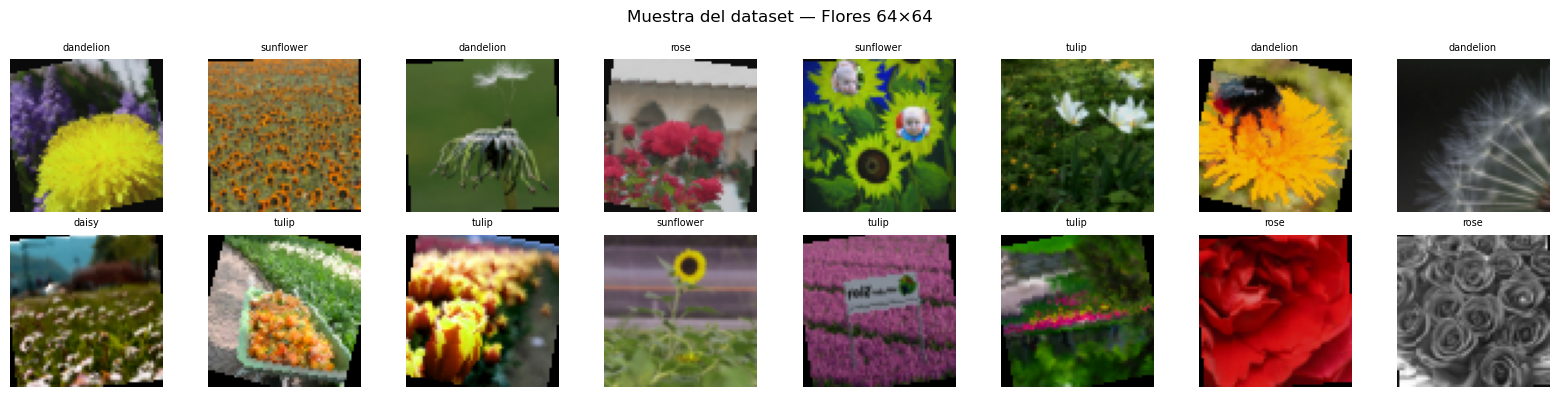

In [4]:
# Visualizar algunas imágenes del dataset
imgs, labels = next(iter(dataloader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = imgs[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)   # Desnormalizar para visualizar
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(dataset.classes[labels[i]], fontsize=7)
plt.suptitle('Muestra del dataset — Flores 64×64', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Arquitectura DCGAN

### 5.1 Generador

El Generador toma un vector de ruido `z` de dimensión 100 y lo transforma en una imagen de 64×64×3.

✅ **Mejora aplicada:** Se reemplazaron las capas `ConvTranspose2d` por **Upsample + Conv2d** para eliminar el artefacto de cuadrícula (*checkerboard artifact*) que aparecía en las imágenes generadas.

```
z (100,1,1) → 512×4×4 → Upsample→ 256×8×8 → Upsample→ 128×16×16 → Upsample→ 64×32×32 → Upsample→ 3×64×64
```

Reglas DCGAN para el Generador:
- **BatchNorm** en todas las capas (excepto la capa de salida)
- **ReLU** como activación en capas intermedias
- **Tanh** en la capa de salida → rango [-1, 1]

In [5]:
class Generador(nn.Module):
    """
    DCGAN Generador — versión mejorada sin checkerboard artifact.
    Se usa Upsample + Conv2d en lugar de ConvTranspose2d para evitar
    el patrón de cuadrícula en las imágenes generadas.
    Entrada:  vector de ruido z de forma (batch, Z_DIM, 1, 1)
    Salida:   imagen de forma (batch, 3, 64, 64)
    """
    def __init__(self, z_dim=Z_DIM, g_feat=G_FEATURES, channels=CHANNELS):
        super(Generador, self).__init__()

        # Capa inicial: proyectar z a mapa espacial 4×4
        self.capa_inicial = nn.Sequential(
            nn.ConvTranspose2d(z_dim, g_feat * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(g_feat * 8),
            nn.ReLU(True)
        )

        # Bloques Upsample + Conv2d (sin checkerboard)
        self.bloque2 = nn.Sequential(
            # ── (512, 4, 4) → (256, 8, 8) ───────────────────────────────────
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(g_feat * 8, g_feat * 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(g_feat * 4),
            nn.ReLU(True)
        )
        self.bloque3 = nn.Sequential(
            # ── (256, 8, 8) → (128, 16, 16) ─────────────────────────────────
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(g_feat * 4, g_feat * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(g_feat * 2),
            nn.ReLU(True)
        )
        self.bloque4 = nn.Sequential(
            # ── (128, 16, 16) → (64, 32, 32) ────────────────────────────────
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(g_feat * 2, g_feat, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(g_feat),
            nn.ReLU(True)
        )
        self.bloque5 = nn.Sequential(
            # ── (64, 32, 32) → (3, 64, 64) — SIN BatchNorm ──────────────────
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(g_feat, channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()   # Salida en rango [-1, 1]
        )

    def forward(self, z):
        x = self.capa_inicial(z)
        x = self.bloque2(x)
        x = self.bloque3(x)
        x = self.bloque4(x)
        return self.bloque5(x)


# Instanciar y verificar
generador = Generador().to(device)
print("=== GENERADOR ===")
print(generador)
z_prueba = torch.randn(1, Z_DIM, 1, 1).to(device)
salida = generador(z_prueba)
print(f"\nEntrada z: {z_prueba.shape}")
print(f"Salida imagen: {salida.shape}  → esperado: (1, 3, 64, 64)")

=== GENERADOR ===
Generador(
  (capa_inicial): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (bloque2): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
  )
  (bloque3): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
  )
  (bloque4): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fal

### 5.2 Discriminador

El Discriminador toma una imagen 64×64×3 y devuelve un escalar que indica si la imagen es real (≈1) o falsa (≈0) usando capas **Conv2d** (convoluciones estándar = "downsampling aprendido").

```
3×64×64 → 64×32×32 → 128×16×16 → 256×8×8 → 512×4×4 → 1×1×1
```

Reglas DCGAN para el Discriminador:
- **BatchNorm** en todas las capas (excepto la capa de entrada)
- **LeakyReLU(0.2)** como activación
- **Sigmoid** en la capa de salida → probabilidad [0, 1]

In [6]:
class Discriminador(nn.Module):
    """
    DCGAN Discriminador.
    Entrada:  imagen de forma (batch, 3, 64, 64)
    Salida:   escalar de probabilidad de forma (batch, 1)
    """
    def __init__(self, d_feat=D_FEATURES, channels=CHANNELS):
        super(Discriminador, self).__init__()

        self.red = nn.Sequential(
            # ── Capa 1: (3, 64, 64) → (64, 32, 32) — SIN BatchNorm ─────────
            nn.Conv2d(channels, d_feat, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # ── Capa 2: (64, 32, 32) → (128, 16, 16) ───────────────────────
            nn.Conv2d(d_feat, d_feat * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(d_feat * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # ── Capa 3: (128, 16, 16) → (256, 8, 8) ────────────────────────
            nn.Conv2d(d_feat * 2, d_feat * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(d_feat * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # ── Capa 4: (256, 8, 8) → (512, 4, 4) ──────────────────────────
            nn.Conv2d(d_feat * 4, d_feat * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(d_feat * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # ── Capa 5: (512, 4, 4) → (1, 1, 1) — SIN BatchNorm ────────────
            nn.Conv2d(d_feat * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()  # Salida en rango [0, 1]
        )

    def forward(self, img):
        return self.red(img).view(-1, 1).squeeze(1)


# Instanciar y verificar
discriminador = Discriminador().to(device)
print("=== DISCRIMINADOR ===")
print(discriminador)
img_prueba = torch.randn(1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE).to(device)
salida = discriminador(img_prueba)
print(f"\nEntrada imagen: {img_prueba.shape}")
print(f"Salida probabilidad: {salida.shape}  → esperado: (1,)")

=== DISCRIMINADOR ===
Discriminador(
  (red): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

Entrada 

### 5.3 Inicialización de pesos

Según el paper de DCGAN, los pesos se inicializan con una distribución normal con **media=0** y **desviación estándar=0.02**.

In [7]:
def inicializar_pesos(modelo):
    """Inicializa los pesos siguiendo las recomendaciones del paper DCGAN."""
    nombre_clase = modelo.__class__.__name__
    if 'Conv' in nombre_clase:
        nn.init.normal_(modelo.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in nombre_clase:
        nn.init.normal_(modelo.weight.data, 1.0, 0.02)
        nn.init.constant_(modelo.bias.data, 0)

generador.apply(inicializar_pesos)
discriminador.apply(inicializar_pesos)
print("✅ Pesos inicializados correctamente")

✅ Pesos inicializados correctamente


## 6. Entrenamiento de la DCGAN

El proceso de entrenamiento sigue los **dos pasos** descritos en el cuadernillo base, pero adaptado a imágenes RGB 64×64:

1. **Entrenar el Discriminador:** con imágenes reales (etiqueta=1) e imágenes falsas generadas (etiqueta=0)
2. **Entrenar el Generador:** intentando engañar al Discriminador (las imágenes falsas deben ser clasificadas como reales)

In [8]:
# Función de pérdida y optimizadores
criterio = nn.BCELoss()

# ✅ LR diferenciado: Discriminador más lento para no dominar al Generador
optimizador_G = optim.Adam(generador.parameters(),     lr=LR_G, betas=(BETA1, 0.999))
optimizador_D = optim.Adam(discriminador.parameters(), lr=LR_D, betas=(BETA1, 0.999))

# Vector de ruido fijo para visualizar el progreso a lo largo del entrenamiento
z_fijo = torch.randn(16, Z_DIM, 1, 1).to(device)

# Listas para guardar el historial de pérdidas
historial_G = []
historial_D = []

print("✅ Optimizadores configurados")
print(f"   Generador     → lr={LR_G}")
print(f"   Discriminador → lr={LR_D}  (más lento para equilibrar)")

✅ Optimizadores configurados
   Generador     → lr=0.0002
   Discriminador → lr=0.0001  (más lento para equilibrar)


Iniciando entrenamiento DCGAN...
  Épocas: 50 | Batch: 64 | Dispositivo: cuda
------------------------------------------------------------
Época [  1/50] | Pérdida D: 1.1929 | Pérdida G: 1.1917


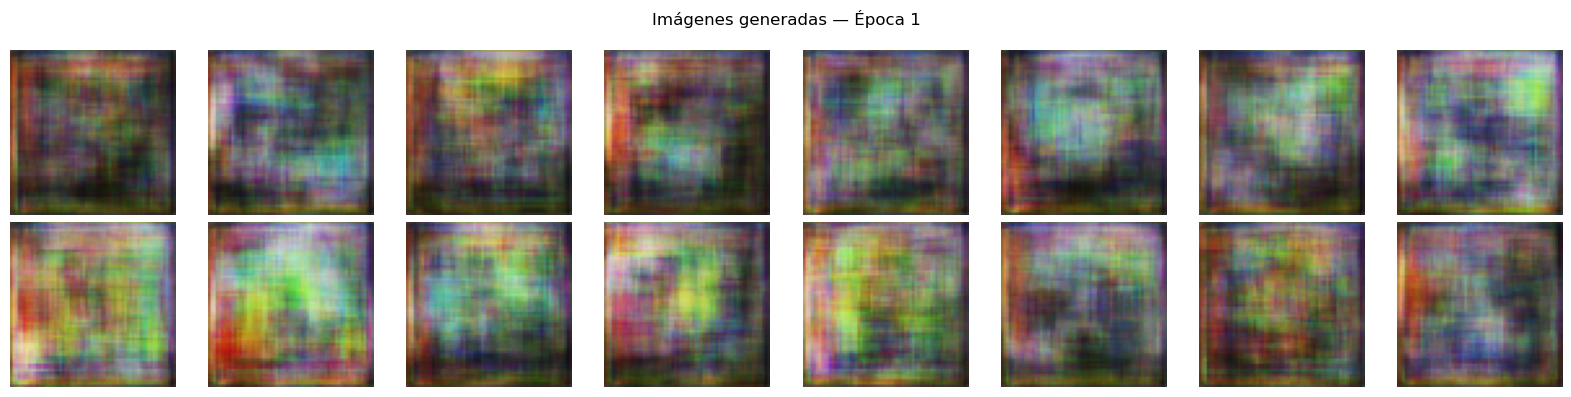

Época [  2/50] | Pérdida D: 0.9361 | Pérdida G: 0.9619
Época [  3/50] | Pérdida D: 0.8434 | Pérdida G: 0.9321
Época [  4/50] | Pérdida D: 0.7968 | Pérdida G: 0.9247
Época [  5/50] | Pérdida D: 0.7568 | Pérdida G: 0.8839
Época [  6/50] | Pérdida D: 0.7440 | Pérdida G: 0.8731
Época [  7/50] | Pérdida D: 0.7323 | Pérdida G: 0.8825
Época [  8/50] | Pérdida D: 0.7301 | Pérdida G: 0.8611
Época [  9/50] | Pérdida D: 0.7219 | Pérdida G: 0.8629
Época [ 10/50] | Pérdida D: 0.7251 | Pérdida G: 0.8770


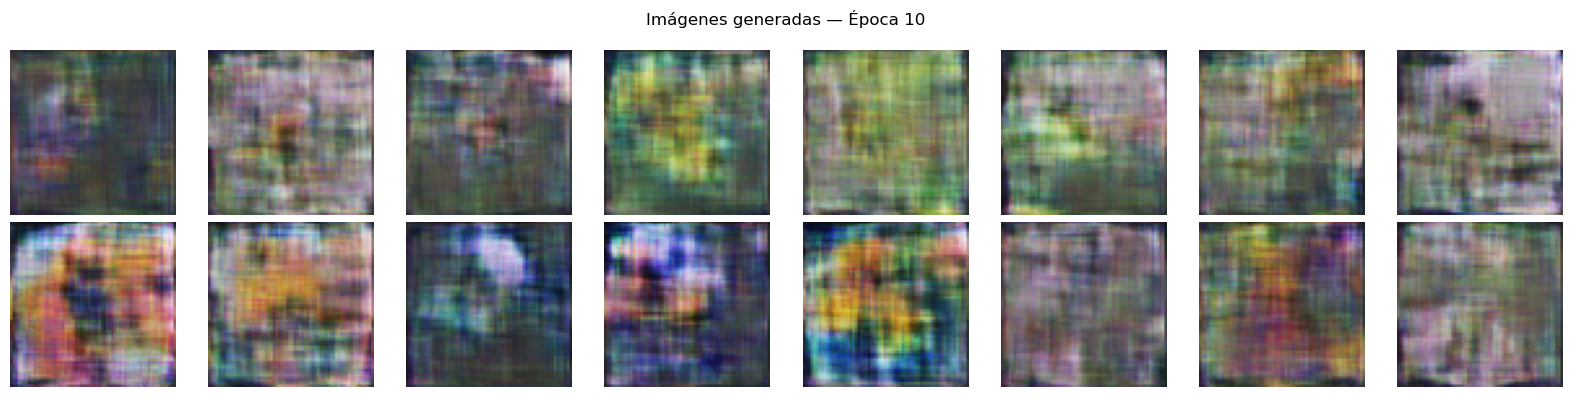

Época [ 11/50] | Pérdida D: 0.7190 | Pérdida G: 0.8682
Época [ 12/50] | Pérdida D: 0.7233 | Pérdida G: 0.8803
Época [ 13/50] | Pérdida D: 0.7299 | Pérdida G: 0.8751
Época [ 14/50] | Pérdida D: 0.7252 | Pérdida G: 0.8454
Época [ 15/50] | Pérdida D: 0.7314 | Pérdida G: 0.8351
Época [ 16/50] | Pérdida D: 0.7229 | Pérdida G: 0.8439
Época [ 17/50] | Pérdida D: 0.7237 | Pérdida G: 0.8374
Época [ 18/50] | Pérdida D: 0.7229 | Pérdida G: 0.8150
Época [ 19/50] | Pérdida D: 0.7226 | Pérdida G: 0.8320
Época [ 20/50] | Pérdida D: 0.7267 | Pérdida G: 0.8482


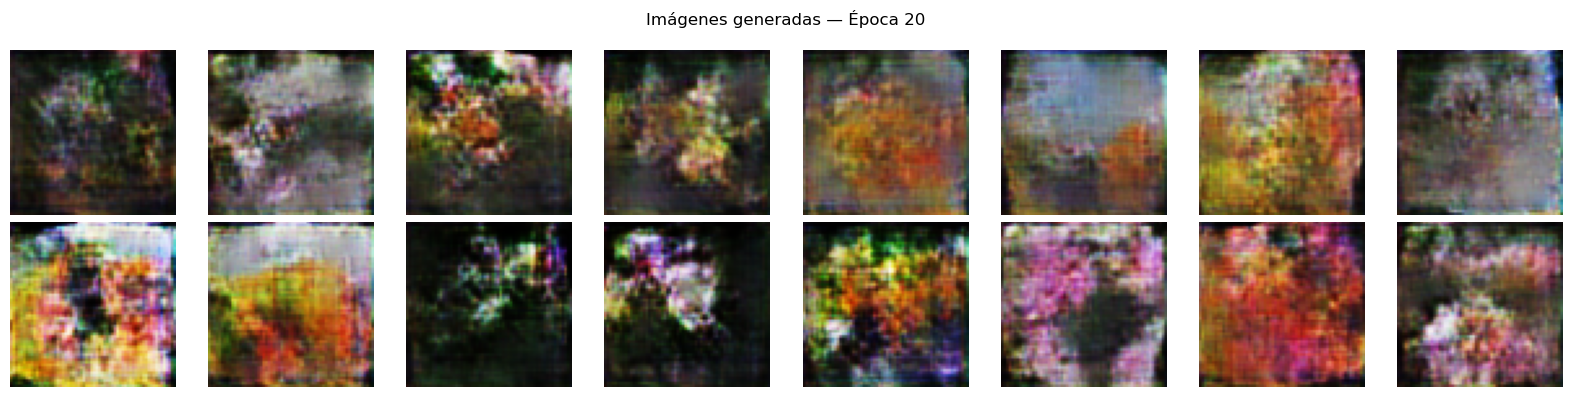

Época [ 21/50] | Pérdida D: 0.7242 | Pérdida G: 0.8502
Época [ 22/50] | Pérdida D: 0.7218 | Pérdida G: 0.8285
Época [ 23/50] | Pérdida D: 0.7187 | Pérdida G: 0.8432
Época [ 24/50] | Pérdida D: 0.7185 | Pérdida G: 0.8403
Época [ 25/50] | Pérdida D: 0.7169 | Pérdida G: 0.8525
Época [ 26/50] | Pérdida D: 0.7166 | Pérdida G: 0.8504
Época [ 27/50] | Pérdida D: 0.7144 | Pérdida G: 0.8654
Época [ 28/50] | Pérdida D: 0.7072 | Pérdida G: 0.8520
Época [ 29/50] | Pérdida D: 0.7119 | Pérdida G: 0.8551
Época [ 30/50] | Pérdida D: 0.7083 | Pérdida G: 0.8498


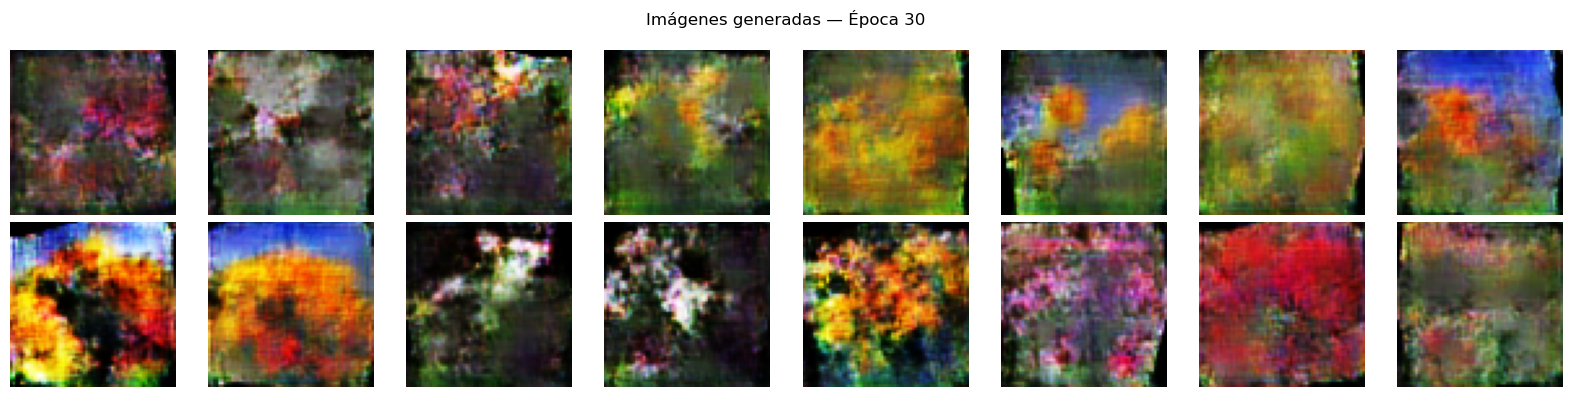

Época [ 31/50] | Pérdida D: 0.7070 | Pérdida G: 0.8580
Época [ 32/50] | Pérdida D: 0.7104 | Pérdida G: 0.8586
Época [ 33/50] | Pérdida D: 0.7056 | Pérdida G: 0.8647
Época [ 34/50] | Pérdida D: 0.7100 | Pérdida G: 0.8556
Época [ 35/50] | Pérdida D: 0.7068 | Pérdida G: 0.8596
Época [ 36/50] | Pérdida D: 0.7057 | Pérdida G: 0.8623
Época [ 37/50] | Pérdida D: 0.7038 | Pérdida G: 0.8667
Época [ 38/50] | Pérdida D: 0.7021 | Pérdida G: 0.8642
Época [ 39/50] | Pérdida D: 0.7065 | Pérdida G: 0.8813
Época [ 40/50] | Pérdida D: 0.7025 | Pérdida G: 0.8701


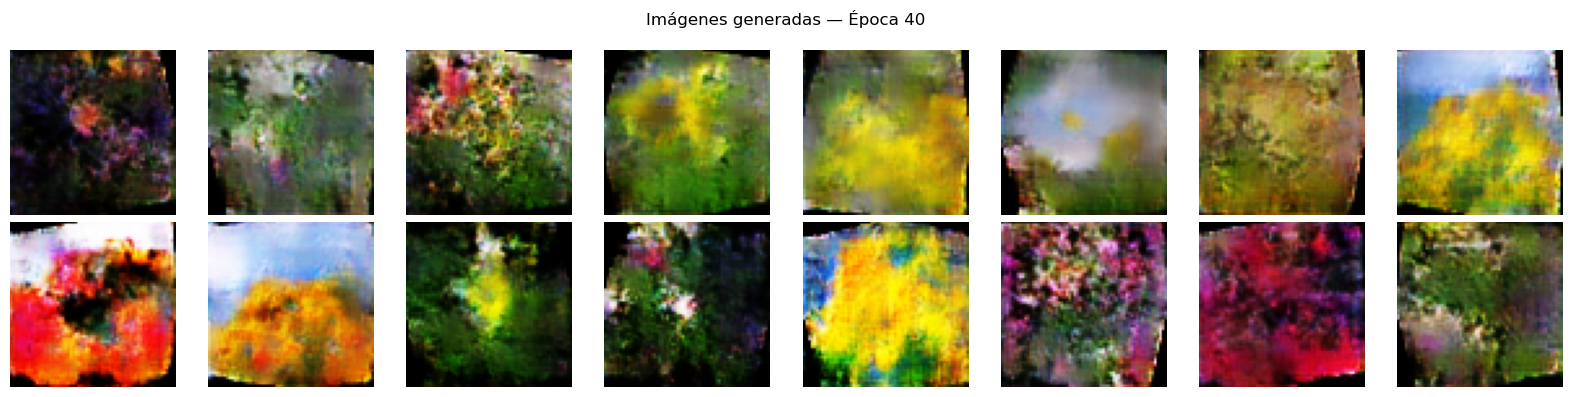

Época [ 41/50] | Pérdida D: 0.7058 | Pérdida G: 0.8699
Época [ 42/50] | Pérdida D: 0.7040 | Pérdida G: 0.8736
Época [ 43/50] | Pérdida D: 0.6991 | Pérdida G: 0.8684
Época [ 44/50] | Pérdida D: 0.7022 | Pérdida G: 0.8678
Época [ 45/50] | Pérdida D: 0.6990 | Pérdida G: 0.8649
Época [ 46/50] | Pérdida D: 0.7075 | Pérdida G: 0.8663
Época [ 47/50] | Pérdida D: 0.7018 | Pérdida G: 0.8523
Época [ 48/50] | Pérdida D: 0.6991 | Pérdida G: 0.8552
Época [ 49/50] | Pérdida D: 0.7066 | Pérdida G: 0.8699
Época [ 50/50] | Pérdida D: 0.6992 | Pérdida G: 0.8637


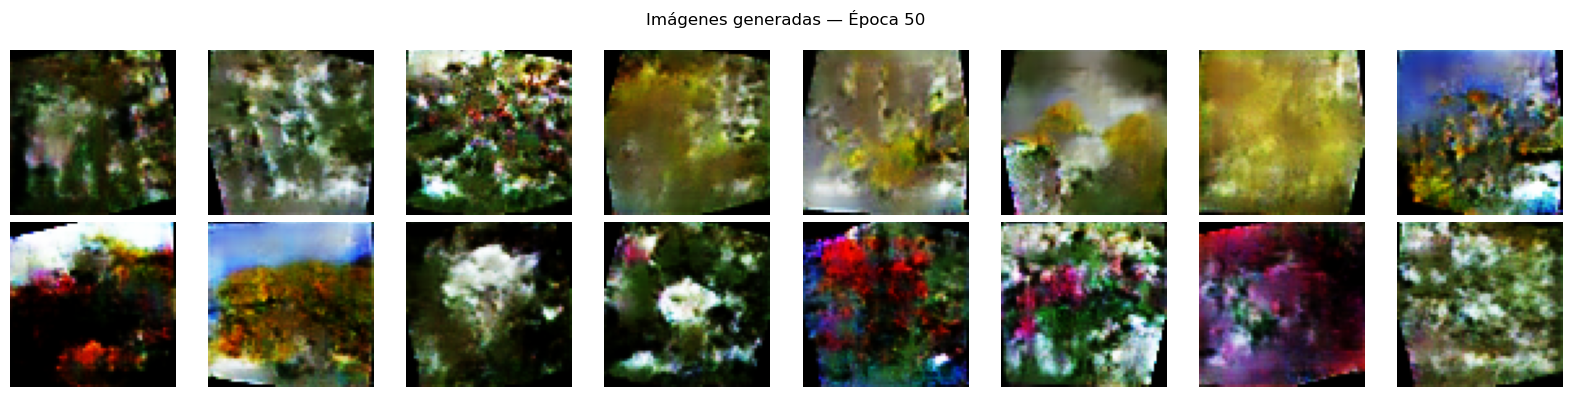


✅ Entrenamiento completado


In [9]:
print("Iniciando entrenamiento DCGAN...")
print(f"  Épocas: {EPOCHS} | Batch: {BATCH_SIZE} | Dispositivo: {device}")
print("-" * 60)

for epoca in range(EPOCHS):
    perdida_D_epoca = 0
    perdida_G_epoca = 0

    for i, (imgs_reales, _) in enumerate(dataloader):
        batch_actual = imgs_reales.size(0)
        imgs_reales = imgs_reales.to(device)

        # ── Etiquetas ────────────────────────────────────────────────────────
        # ✅ Label Smoothing: etiquetas reales = 0.9 (no 1.0) para evitar que
        #    el Discriminador se vuelva demasiado confiado
        etiquetas_reales = torch.full((batch_actual,), LABEL_SMOOTH).to(device)
        etiquetas_falsas = torch.zeros(batch_actual).to(device)

        # ════════════════════════════════════════════════════════════════════
        # PASO 1: Entrenar el Discriminador
        # Maximizar: log(D(x)) + log(1 - D(G(z)))
        # ════════════════════════════════════════════════════════════════════
        optimizador_D.zero_grad()

        # 1a) Pérdida con imágenes REALES
        pred_reales = discriminador(imgs_reales)
        perdida_D_real = criterio(pred_reales, etiquetas_reales)

        # 1b) Pérdida con imágenes FALSAS (generadas)
        z = torch.randn(batch_actual, Z_DIM, 1, 1).to(device)
        imgs_falsas = generador(z)
        pred_falsas = discriminador(imgs_falsas.detach())  # .detach() evita actualizar el Generador
        perdida_D_falsa = criterio(pred_falsas, etiquetas_falsas)

        # 1c) Pérdida total del Discriminador y actualización de pesos
        perdida_D = (perdida_D_real + perdida_D_falsa) / 2
        perdida_D.backward()
        optimizador_D.step()

        # ════════════════════════════════════════════════════════════════════
        # PASO 2: Entrenar el Generador (G_STEPS veces por cada paso de D)
        # ✅ Se entrena 2 veces para compensar que D aprende más rápido
        # Minimizar: log(1 - D(G(z)))  ≡  Maximizar: log(D(G(z)))
        # ════════════════════════════════════════════════════════════════════
        perdida_G = None
        for _ in range(G_STEPS):
            optimizador_G.zero_grad()
            # Generar nuevo ruido en cada paso del Generador
            z = torch.randn(batch_actual, Z_DIM, 1, 1).to(device)
            imgs_falsas = generador(z)
            # El Generador quiere engañar al Discriminador → etiquetas como reales
            etiquetas_gen = torch.ones(batch_actual).to(device)
            pred_gen = discriminador(imgs_falsas)
            perdida_G = criterio(pred_gen, etiquetas_gen)
            perdida_G.backward()
            optimizador_G.step()

        perdida_D_epoca += perdida_D.item()
        perdida_G_epoca += perdida_G.item()

    # Promediar pérdidas de la época
    perdida_D_media = perdida_D_epoca / len(dataloader)
    perdida_G_media = perdida_G_epoca / len(dataloader)
    historial_D.append(perdida_D_media)
    historial_G.append(perdida_G_media)

    print(f"Época [{epoca+1:3d}/{EPOCHS}] | Pérdida D: {perdida_D_media:.4f} | Pérdida G: {perdida_G_media:.4f}")

    # Visualizar imágenes generadas cada 10 épocas
    if (epoca + 1) % 10 == 0 or epoca == 0:
        generador.eval()
        with torch.no_grad():
            imgs_gen = generador(z_fijo).cpu()
        generador.train()

        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        for j, ax in enumerate(axes.flatten()):
            img = imgs_gen[j].permute(1, 2, 0).numpy()
            img = (img * 0.5 + 0.5).clip(0, 1)
            ax.imshow(img)
            ax.axis('off')
        plt.suptitle(f'Imágenes generadas — Época {epoca+1}', fontsize=12)
        plt.tight_layout()
        plt.show()

print("\n✅ Entrenamiento completado")

## 7. Resultados y análisis

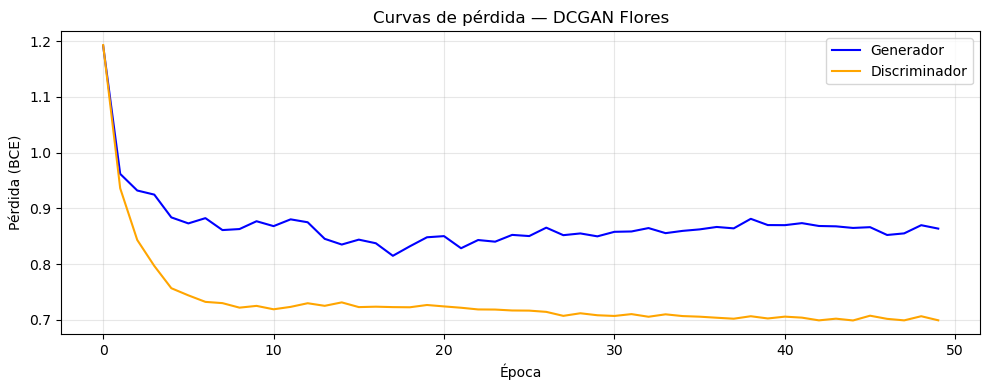

In [10]:
# Curvas de pérdida
plt.figure(figsize=(10, 4))
plt.plot(historial_G, label='Generador',     color='blue')
plt.plot(historial_D, label='Discriminador', color='orange')
plt.xlabel('Época')
plt.ylabel('Pérdida (BCE)')
plt.title('Curvas de pérdida — DCGAN Flores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

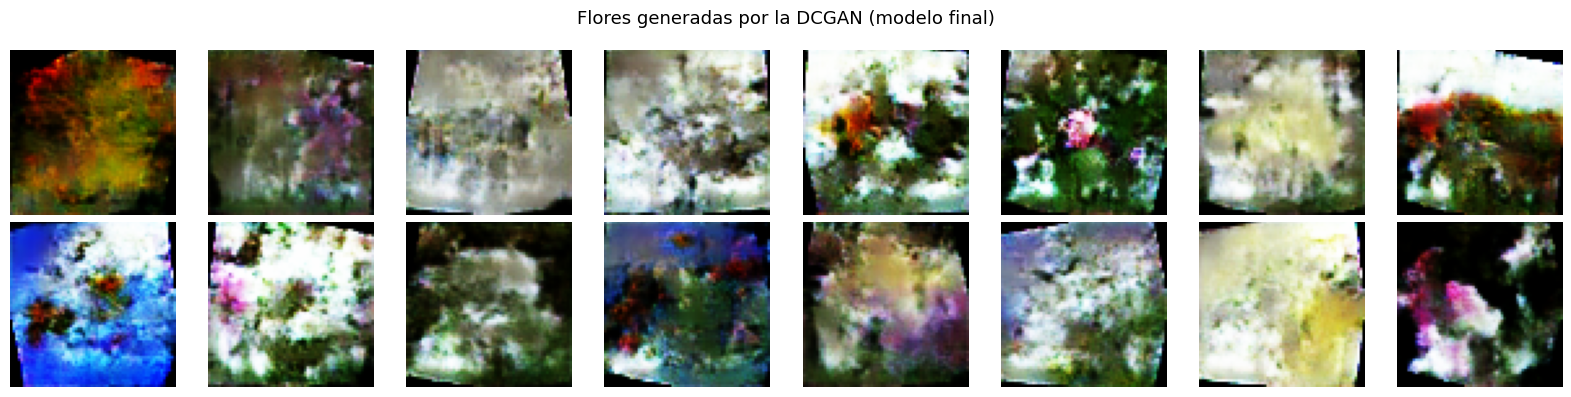

✅ Imagen guardada como 'flores_generadas.png'


In [11]:
# Generar nuevas flores con el modelo entrenado
generador.eval()
with torch.no_grad():
    z_nuevo = torch.randn(16, Z_DIM, 1, 1).to(device)
    flores_generadas = generador(z_nuevo).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = flores_generadas[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Flores generadas por la DCGAN (modelo final)', fontsize=13)
plt.tight_layout()
plt.savefig('flores_generadas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Imagen guardada como 'flores_generadas.png'")

## 8. Guardar el modelo

In [12]:
# Guardar los pesos del Generador y del Discriminador
torch.save(generador.state_dict(),     'dcgan_generador_flores22.pth')
torch.save(discriminador.state_dict(), 'dcgan_discriminador_flores22.pth')
print("✅ Modelos guardados:")
print("   dcgan_generador_flores22.pth")
print("   dcgan_discriminador_flores22.pth")



✅ Modelos guardados:
   dcgan_generador_flores22.pth
   dcgan_discriminador_flores22.pth


## 9. Cargar el modelo y generar flores

Esta celda permite cargar el generador guardado para generar nuevas flores sin necesidad de volver a entrenar.

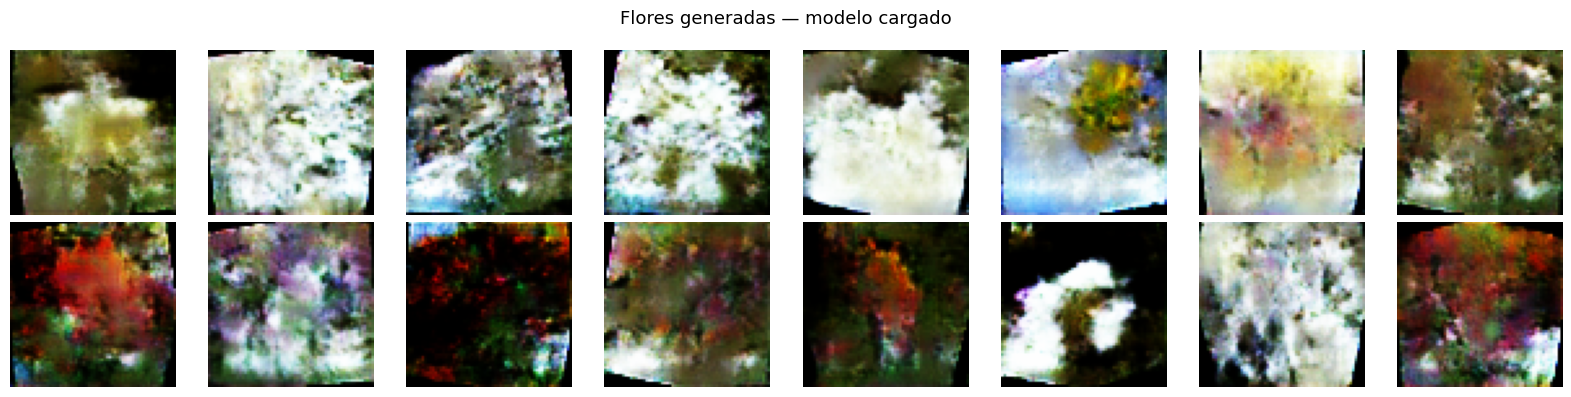

✅ Generación exitosa con el modelo cargado


In [13]:
# Cargar el generador guardado
gen_cargado = Generador().to(device)
gen_cargado.load_state_dict(torch.load('dcgan_generador_flores22.pth', map_location=device))
gen_cargado.eval()

# Generar flores con el modelo cargado
with torch.no_grad():
    z = torch.randn(16, Z_DIM, 1, 1).to(device)
    nuevas_flores = gen_cargado(z).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = nuevas_flores[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Flores generadas — modelo cargado', fontsize=13)
plt.tight_layout()
plt.show()
print("✅ Generación exitosa con el modelo cargado")

## 10. Resumen

En este cuadernillo implementamos una **DCGAN (Deep Convolutional GAN)** capaz de generar imágenes sintéticas de flores de 64×64 píxeles en color RGB.

### Puntos clave aprendidos:

- La **DCGAN** reemplaza las capas densas de la GAN simple por capas convolucionales, lo que permite trabajar con imágenes más grandes y a color.
- El **Generador** usa `Upsample + Conv2d` (en lugar de `ConvTranspose2d`) para evitar el artefacto de cuadrícula (*checkerboard*) en las imágenes generadas.
- El **Discriminador** usa `Conv2d` estándar para hacer *downsampling* de la imagen y clasificarla.
- El **BatchNorm** es fundamental para estabilizar el entrenamiento.
- El **Data Augmentation** (volteo, rotación, ColorJitter) aplicado a todas las clases permite que el modelo aprenda más variedad con el mismo dataset.
- El **Label Smoothing** (0.9 en lugar de 1.0) evita que el Discriminador se vuelva demasiado confiado y domine al Generador.
- El dataset **Flowers Recognition** (~4,242 imágenes, 5 clases) cumple con el requisito mínimo de **64×64 píxeles** establecido para el proyecto.

### Mejoras aplicadas respecto a la versión base:
| Problema | Solución aplicada |
|---|---|
| Discriminador dominante (pérdida ~0) | LR diferenciado: LR_D=0.0001 < LR_G=0.0002 |
| Generador no mejora (pérdida ~4) | G_STEPS=2: entrena 2 veces por cada paso del D |
| Discriminador sobreconfiado | Label Smoothing: etiquetas reales = 0.9 |
| Checkerboard en imágenes | Upsample + Conv2d en lugar de ConvTranspose2d |
| Pocas variaciones de datos | Data Augmentation en todas las clases |

> 💡 Con más de 10,000 imágenes y técnicas avanzadas como *spectral normalization* o *progressive growing* se pueden obtener resultados aún más nítidos.